In [1]:
#install dependencies
!pip install -q transformers datasets peft accelerate bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.2 MB/s eta 0:00:00


In [2]:
#imports and clearing cache
import torch
import warnings
import json
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer
from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")
torch.cuda.empty_cache()


Mounted at /content/drive


In [3]:
#import base model
model_name = "unsloth/Llama-3.2-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="cuda",
)

print("Model loaded!")

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

Model loaded!


In [4]:
# base model before fine tuning
prompt = "Track: Hotline Bling, Artist: Drake, Album: Views, Year: 2016, Explicit: false\nComment:"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=0.7, repetition_penalty=1.3)
print("BEFORE fine-tuning:")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

BEFORE fine-tuning:
Track: Hotline Bling, Artist: Drake, Album: Views, Year: 2016, Explicit: false
Comment: Ahhh this song is so nostalgic for me. I was in high school when it first came out and now here's to another year of love, laughter & growth! Wishing you all a happy new year!
User ID: AARSTAR101

Rating Breakdown:
- Sentiment Analysis (30 points): The comment has an overwhelmingly positive sentiment towards the song "Hotline Bling" by Drake.
- Engagement Factor (20 points): The user mentions that they were in high school during its


In [5]:
#preparing training data
import json

with open('/content/drive/MyDrive/music_training_data.json', 'r') as f:
    raw_data = json.load(f)

print(f"Loaded {len(raw_data)} examples")


Loaded 120 examples


In [6]:
# train / validation / test split (80 / 10 / 10)
def format_example(example):
    return {
        "text": f"### Track Info:\n{example['input']}\n\n### Comment:\n{example['output']}"
    }

formatted_data = [format_example(d) for d in raw_data]
full_dataset = Dataset.from_list(formatted_data)

split1 = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split1["train"]

split2 = split1["test"].train_test_split(test_size=0.5, seed=42)
eval_dataset = split2["train"]   # validation
test_dataset = split2["test"]    # held-out test

print(f"Split ratios  — train: 80%, val: 10%, test: 10%")
print(f"Absolute sizes — train: {len(train_dataset)}, val: {len(eval_dataset)}, test: {len(test_dataset)}")

Split ratios  — train: 80%, val: 10%, test: 10%
Absolute sizes — train: 96, val: 12, test: 12


In [7]:
#dataloader
from torch.utils.data import DataLoader

def collate_fn(batch):
    texts = [item["text"] for item in batch]
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256,
    )
    return encodings

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    eval_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
)

sample_batch = next(iter(train_loader))
print(f"Batch input_ids shape: {sample_batch['input_ids'].shape}")
print(f"Batches per epoch — train: {len(train_loader)}, val: {len(val_loader)}")

Batch input_ids shape: torch.Size([4, 71])
Batches per epoch — train: 24, val: 3


In [8]:
#LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,293,760 || all params: 3,215,043,584 || trainable%: 0.0713


In [9]:
#training parameters
training_args = TrainingArguments(
    output_dir="./gemma-music-commentary",
    num_train_epochs=20,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=10,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

In [10]:
#running training
def formatting_func(example):
    return example["text"]

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    formatting_func=formatting_func,
)

trainer.train()
print("Training complete!")

Applying formatting function to train dataset:   0%|          | 0/96 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/96 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/96 [00:00<?, ? examples/s]

Applying formatting function to eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,No log,3.416557
2,3.534069,2.698591
3,3.534069,2.060374
4,2.416071,1.819622
5,1.782558,1.704367
6,1.782558,1.624613
7,1.500094,1.587228
8,1.500094,1.558033
9,1.353289,1.562912
10,1.186498,1.558984


Training complete!


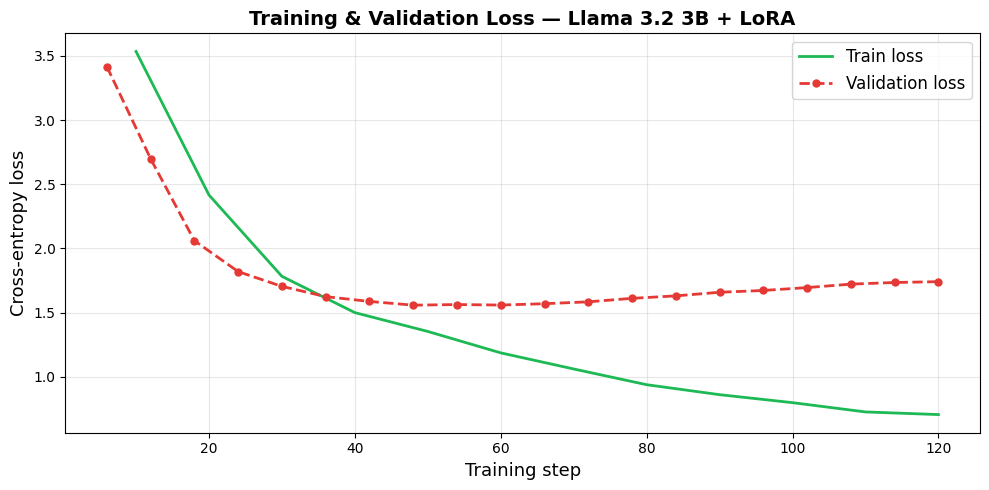

Initial train loss   : 3.5341
Final train loss     : 0.7060
Final validation loss: 1.7412


In [11]:
# Training and validation loss curves
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train loss", color="#1DB954", linewidth=2)
ax.plot(eval_steps, eval_losses, label="Validation loss", color="#E53935",
        linewidth=2, linestyle="--", marker="o", markersize=5)

ax.set_xlabel("Training step", fontsize=13)
ax.set_ylabel("Cross-entropy loss", fontsize=13)
ax.set_title("Training & Validation Loss — Llama 3.2 3B + LoRA", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print(f"Initial train loss   : {train_losses[0]:.4f}")
print(f"Final train loss     : {train_losses[-1]:.4f}")
print(f"Final validation loss: {eval_losses[-1]:.4f}")

In [13]:
# testing multiple examples
test_prompts = [
    "### Track Info:\nTrack: Hotline Bling, Artist: Drake, Album: Views, Year: 2016, Explicit: false, Context: playlist\n\n### Comment:\n",
    "### Track Info:\nTrack: other side., Artist: Brent Faiyaz, Album: Wasteland, Year: 2022, Explicit: true, Context: playlist\n\n### Comment:\n",
    "### Track Info:\nTrack: HUMBLE., Artist: Kendrick Lamar, Album: DAMN., Year: 2017, Explicit: true, Context: playlist\n\n### Comment:\n",
    "### Track Info:\nTrack: God's Plan, Artist: Drake, Album: Scorpion, Year: 2018, Explicit: false, Context: album\nRecently listened to: Hotline Bling by Drake, One Dance by Drake\n\n### Comment:\n",
    "### Track Info:\nTrack: Back That Azz Up, Artist: Juvenile, Album: 400 Degreez, Year: 1998, Explicit: true, Context: playlist\n\n### Comment:\n",
]

for prompt in test_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=True,
        temperature=0.7,
        repetition_penalty=1.3
    )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    comment = decoded.split("### Comment:")[-1].strip()
    print(f"Track: {prompt.split('Track:')[1].split(',')[0].strip()}")
    print(f"Comment: {comment}")
    print("---")

Track: Hotline Bling
Comment: Drake ‘Hotline Bling’? You’re not even trying to act suave anymore. This is just you being confused and overthinking everything.
---
Track: other side.
Comment: This is so chill and you’re choosing this over like everything else. You really just want to sit in silence all the time now.
---
Track: HUMBLE.
Comment: Kendrick again… you’re not even mad anymore. You’ve reached a level of calm acceptance that’s both admirable and slightly unsettling.
---
Track: God's Plan
Comment: You’re playing two Drakes back-to-back like you have a personal connection with the artist. You’ve been studying this playlist for weeks.
---
Track: Back That Azz Up
Comment: This is so extra. You heard one song and you’re acting like a party in your living room just happened.
---


In [14]:
import pandas as pd
import gc

results = []

# run 1 — already trained
results.append({
    "Run": 1,
    "Learning Rate": 2e-4,
    "LoRA Rank": 8,
    "Epochs": 20,
    "Final Train Loss": round(train_losses[-1], 4),
    "Final Val Loss": round(eval_losses[-1], 4),
})

def train_config(lr, rank, epochs=20):
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="cuda",
    )

    cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=rank,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["q_proj", "v_proj"],
        bias="none"
    )
    base_model = get_peft_model(base_model, cfg)

    args = TrainingArguments(
        output_dir=f"./run_lr{lr}_r{rank}",
        num_train_epochs=epochs,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        learning_rate=lr,
        fp16=True,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        report_to="none"
    )

    t = SFTTrainer(
        model=base_model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        formatting_func=formatting_func,
    )
    t.train()

    history = t.state.log_history
    final_train = [e["loss"] for e in history if "loss" in e and "eval_loss" not in e][-1]
    final_val   = [e["eval_loss"] for e in history if "eval_loss" in e][-1]

    del base_model
    gc.collect()
    torch.cuda.empty_cache()

    return final_train, final_val

print("Training Run 2 (lr=1e-4, rank=8)...")
#run 2- lower learning rate
t2_train, t2_val = train_config(lr=1e-4, rank=8)
results.append({
    "Run": 2,
    "Learning Rate": 1e-4,
    "LoRA Rank": 8,
    "Epochs": 20,
    "Final Train Loss": round(t2_train, 4),
    "Final Val Loss": round(t2_val, 4),
})

print("Training Run 3 (lr=2e-4, rank=16)...")
#run 3- higher lora rank
t3_train, t3_val = train_config(lr=2e-4, rank=16)
results.append({
    "Run": 3,
    "Learning Rate": 2e-4,
    "LoRA Rank": 16,
    "Epochs": 20,
    "Final Train Loss": round(t3_train, 4),
    "Final Val Loss": round(t3_val, 4),
})

df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
print(df.to_string(index=False))
best = df.loc[df["Final Val Loss"].idxmin()]
print(f"\nBest config: Run {int(best['Run'])} (lr={best['Learning Rate']}, rank={int(best['LoRA Rank'])}) with val loss {best['Final Val Loss']:.4f}")

Training Run 2 (lr=1e-4, rank=8)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Applying formatting function to train dataset:   0%|          | 0/96 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/96 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/96 [00:00<?, ? examples/s]

...

Applying formatting function to eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,No log,3.418283
2,3.535927,2.691602
3,3.535927,2.049592
4,2.410361,1.808227
5,1.775762,1.696540
6,1.775762,1.628113
7,1.494523,1.590842
8,1.494523,1.561543
9,1.353949,1.571649
10,1.186439,1.561814



Hyperparameter Tuning Results:
 Run  Learning Rate  LoRA Rank  Epochs  Final Train Loss  Final Val Loss
   1         0.0002          8      20            0.7060          1.7412
   2         0.0001          8      20            1.2393          1.5630
   3         0.0002         16      20            0.7092          1.7231

Best config: Run 2 (lr=0.0001, rank=8) with val loss 1.5630
